In [1]:
import pandas as pd

trades = pd.read_csv("data/historical_data.csv")
fear = pd.read_csv("data/fear_greed_index.csv")

print(trades.shape)
print(fear.shape)

(211224, 16)
(2644, 4)


In [2]:
print("Trades Columns:")
print(trades.columns)

print("\nFear & Greed Columns:")
print(fear.columns)

Trades Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [3]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [4]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [5]:
print("Trades Missing Values:")
print(trades.isnull().sum())

print("\nFear Missing Values:")
print(fear.isnull().sum())

Trades Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [7]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trades["Date"] = trades["Timestamp IST"].dt.date

In [8]:
fear["date"] = pd.to_datetime(fear["date"])

fear["Date"] = fear["date"].dt.date

In [9]:
merged = pd.merge(
    trades,
    fear[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

In [10]:
print(merged.shape)

merged[["Date", "classification", "value"]].head(10)

(211224, 19)


,Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0
5,2024-12-02,Extreme Greed,80.0
6,2024-12-02,Extreme Greed,80.0
7,2024-12-02,Extreme Greed,80.0
8,2024-12-02,Extreme Greed,80.0
9,2024-12-02,Extreme Greed,80.0


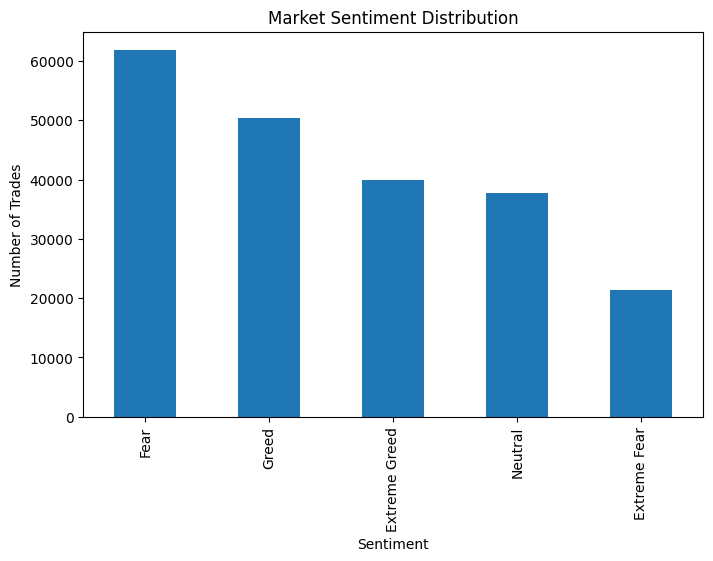

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

merged["classification"].value_counts().plot(kind="bar")

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64


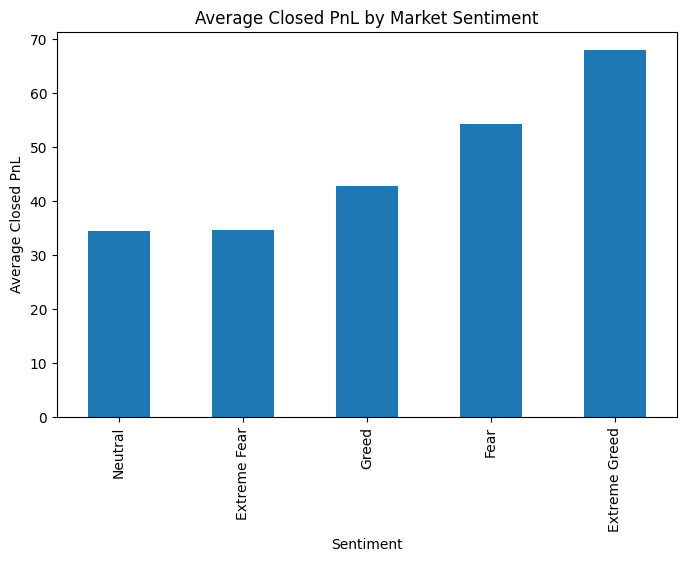

In [12]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean().sort_values()

print(avg_pnl)

plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

classification
Extreme Fear     7.391102e+05
Neutral          1.292921e+06
Greed            2.150129e+06
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Name: Closed PnL, dtype: float64


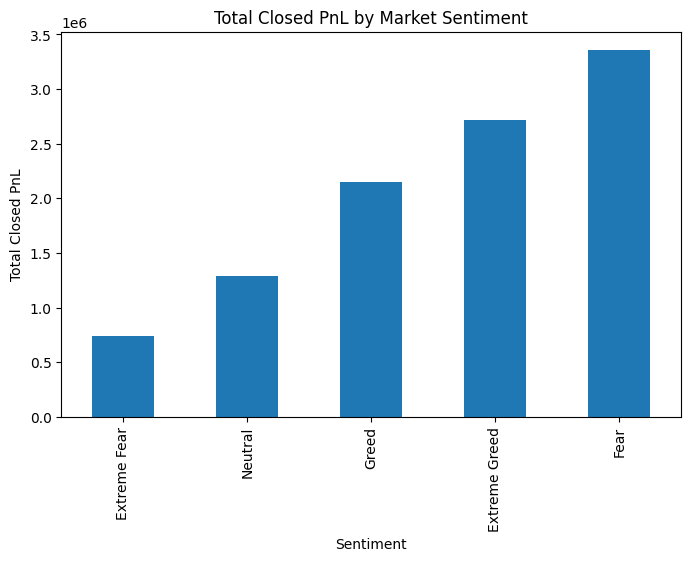

In [13]:
total_pnl = merged.groupby("classification")["Closed PnL"].sum().sort_values()

print(total_pnl)

plt.figure(figsize=(8,5))

total_pnl.plot(kind="bar")

plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Total Closed PnL")

plt.show()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


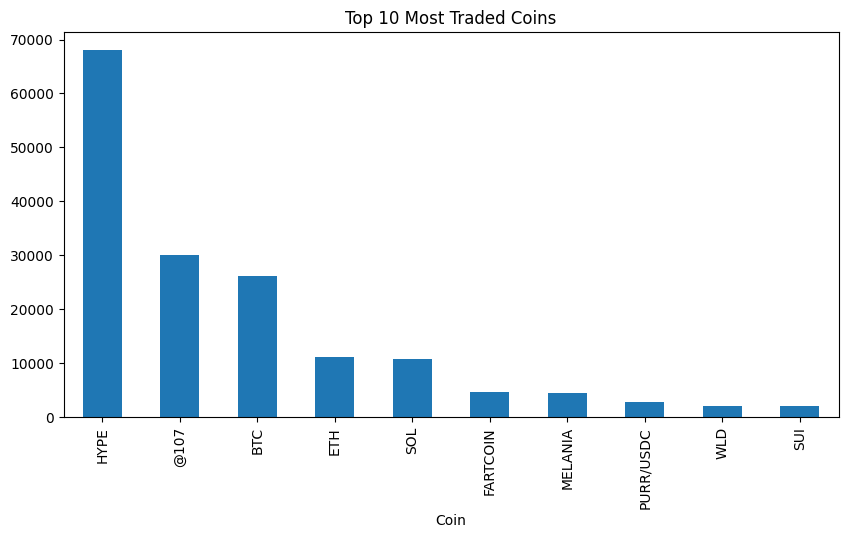

In [14]:
top_coin = merged["Coin"].value_counts().head(10)

print(top_coin)

plt.figure(figsize=(10,5))

top_coin.plot(kind="bar")

plt.title("Top 10 Most Traded Coins")

plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


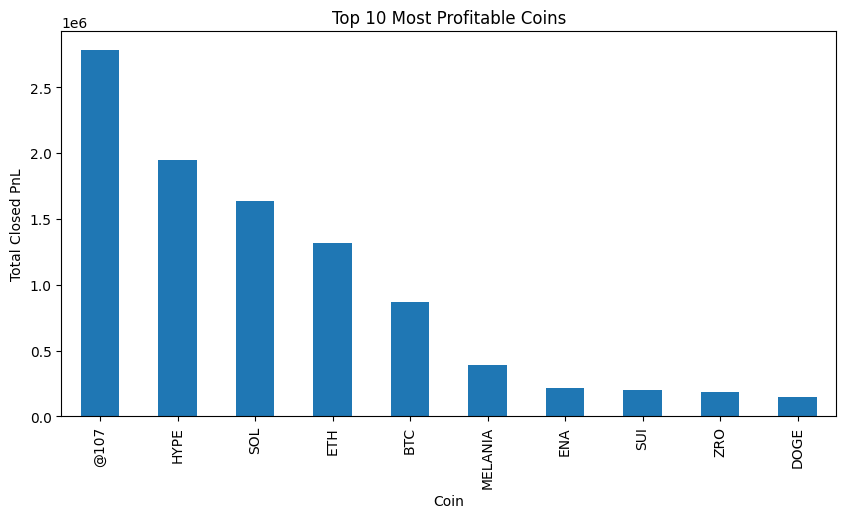

In [15]:
top_profit = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_profit)

plt.figure(figsize=(10,5))
top_profit.plot(kind="bar")
plt.title("Top 10 Most Profitable Coins")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")
plt.show()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


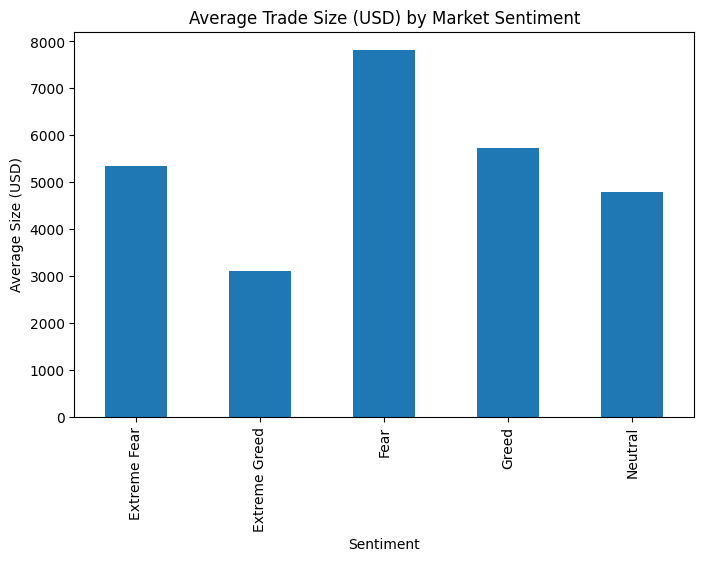

In [16]:
avg_size = merged.groupby("classification")["Size USD"].mean()

print(avg_size)

plt.figure(figsize=(8,5))
avg_size.plot(kind="bar")
plt.title("Average Trade Size (USD) by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Size (USD)")
plt.show()

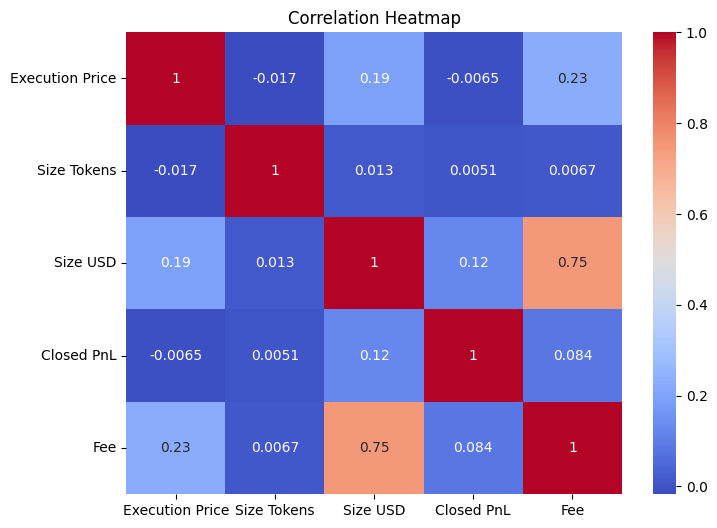

In [17]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    merged[
        ["Execution Price", "Size Tokens", "Size USD", "Closed PnL", "Fee"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

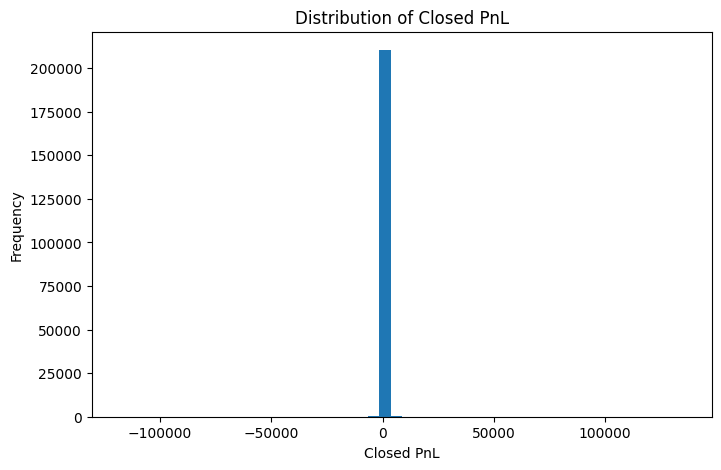

In [18]:
plt.figure(figsize=(8,5))

plt.hist(merged["Closed PnL"], bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


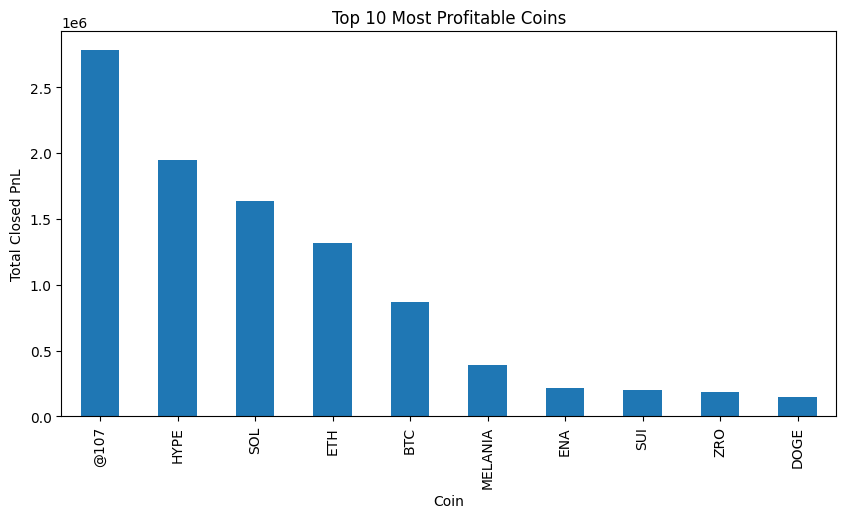

In [19]:
top_profit = merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

print(top_profit)

plt.figure(figsize=(10,5))
top_profit.plot(kind="bar")
plt.title("Top 10 Most Profitable Coins")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")
plt.show()

Direction
Auto-Deleveraging            5.747846e+04
Buy                          0.000000e+00
Close Long                   3.622929e+06
Close Short                  3.709800e+06
Liquidated Isolated Short   -1.275291e+04
Long > Short                 1.991379e+03
Open Long                    0.000000e+00
Open Short                   0.000000e+00
Sell                         2.906748e+06
Settlement                  -2.921537e+01
Short > Long                 1.079333e+04
Spot Dust Conversion         0.000000e+00
Name: Closed PnL, dtype: float64


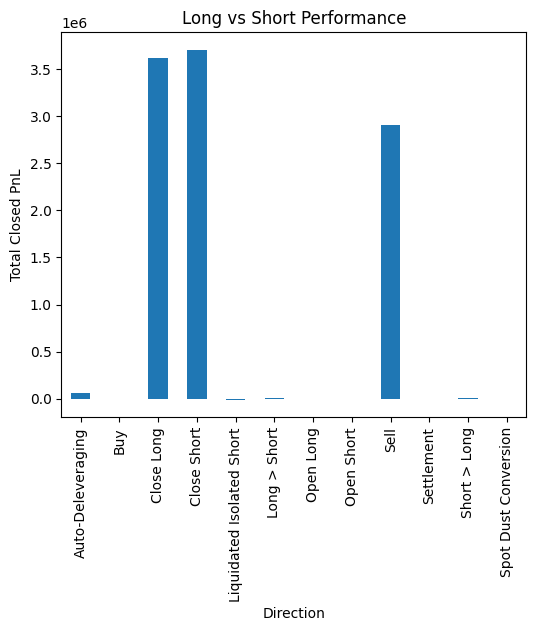

In [20]:
direction_pnl = merged.groupby("Direction")["Closed PnL"].sum()

print(direction_pnl)

plt.figure(figsize=(6,5))
direction_pnl.plot(kind="bar")

plt.title("Long vs Short Performance")
plt.xlabel("Direction")
plt.ylabel("Total Closed PnL")

plt.show()

classification
Extreme Greed    3112.251565
Neutral          4782.732661
Extreme Fear     5349.731843
Greed            5736.884375
Fear             7816.109931
Name: Size USD, dtype: float64


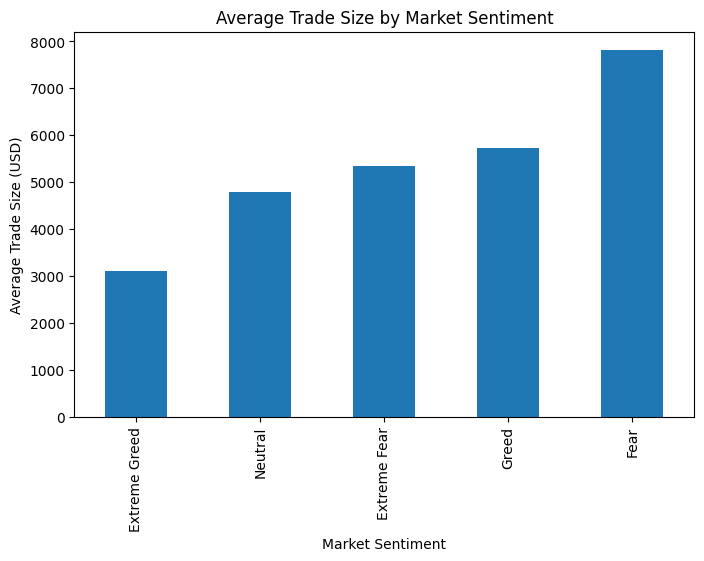

In [21]:
avg_size = merged.groupby("classification")["Size USD"].mean().sort_values()

print(avg_size)

plt.figure(figsize=(8,5))
avg_size.plot(kind="bar")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

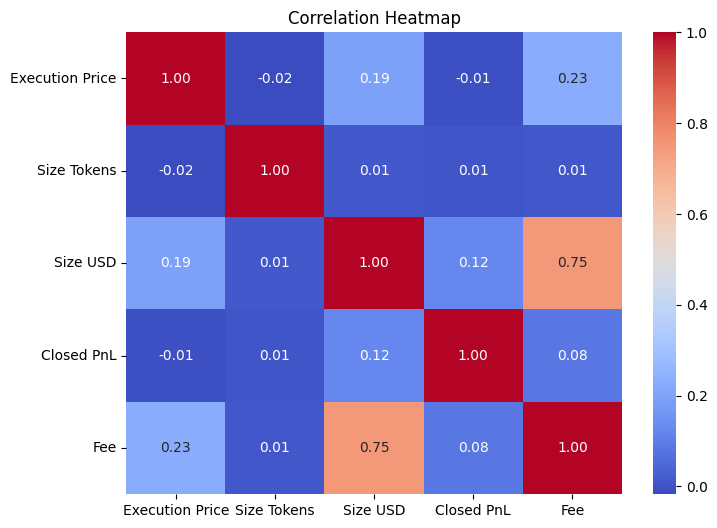

In [22]:
plt.figure(figsize=(8,6))

corr = merged[[
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

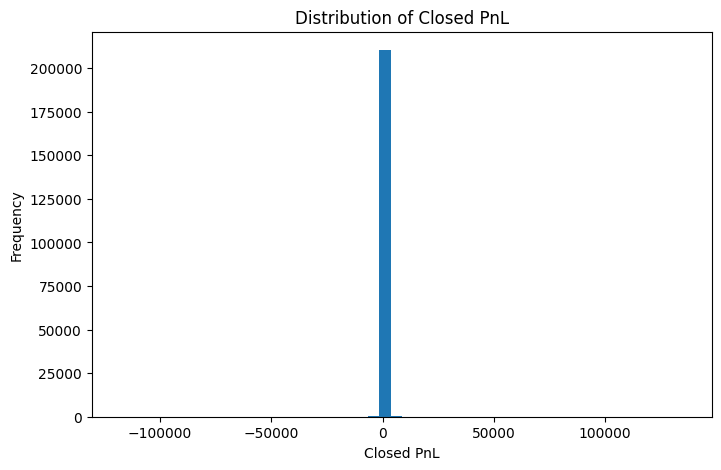

In [23]:
plt.figure(figsize=(8,5))

plt.hist(merged["Closed PnL"], bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

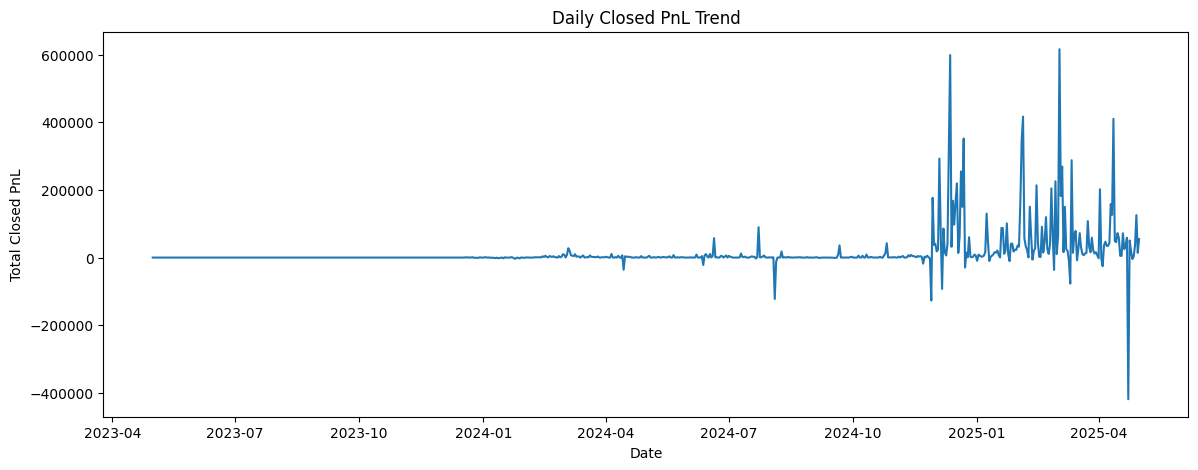

In [24]:
daily_profit = merged.groupby("Date")["Closed PnL"].sum()

plt.figure(figsize=(14,5))

daily_profit.plot()

plt.title("Daily Closed PnL Trend")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL")

plt.show()

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


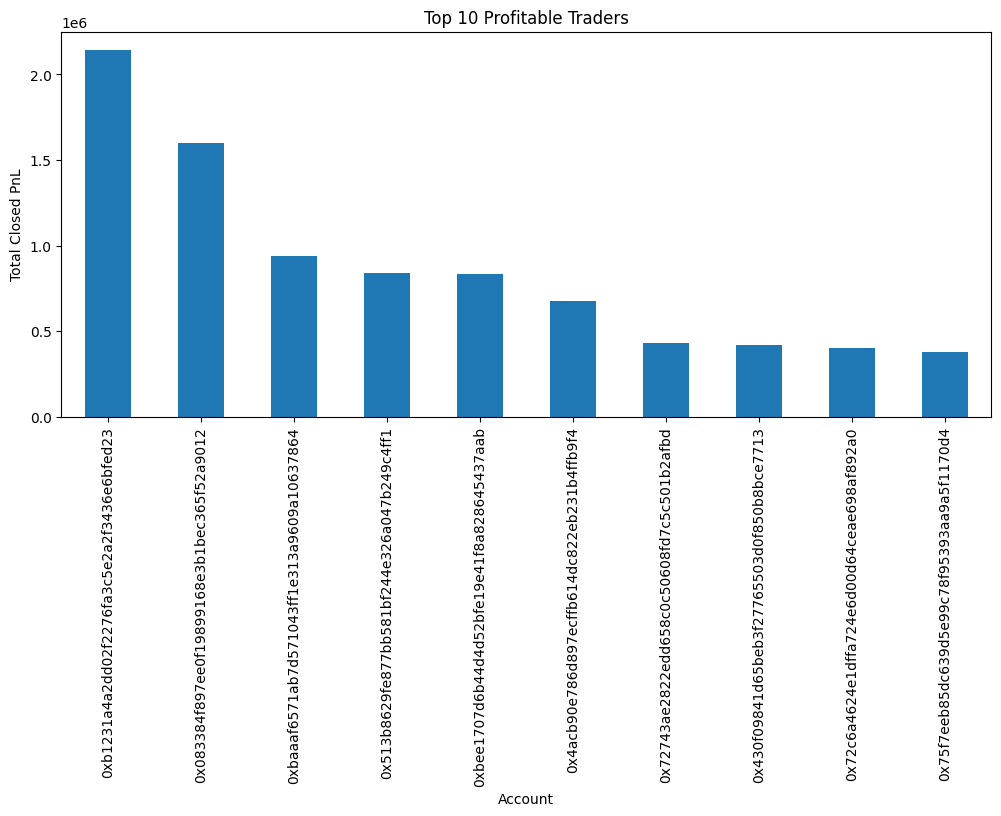

In [25]:
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

print(top_traders)

plt.figure(figsize=(12,5))
top_traders.plot(kind="bar")

plt.title("Top 10 Profitable Traders")
plt.xlabel("Account")
plt.ylabel("Total Closed PnL")

plt.show()

In [26]:
from scipy.stats import ttest_ind

fear_pnl = merged[merged["classification"] == "Fear"]["Closed PnL"]
greed_pnl = merged[merged["classification"] == "Greed"]["Closed PnL"]

t_stat, p_value = ttest_ind(fear_pnl, greed_pnl)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("There is a statistically significant difference between Fear and Greed market profits.")
else:
    print("There is no statistically significant difference between Fear and Greed market profits.")

T-Statistic: 1.884727797757762
P-Value: 0.059469181099708564
There is no statistically significant difference between Fear and Greed market profits.


# PrimeTrade.ai Internship Assessment

## Trader Performance Analysis Based on Bitcoin Market Sentiment

**Name:** Nukala Rishitha